# Institutional Holdings from SEC 13F Bulk Data

**Chapter 4: Fundamental and Alternative Data**
**Docker image**: `ml4t`
**Section Reference**: See Section 4.1 for SEC filing concepts

## Purpose

Work with the SEC's quarterly 13F-HR bulk data set as a whole: ~80 MB per
quarter gives ~3M holdings across ~7K institutional managers. Form 13F
requires investment managers with >$100M in qualifying securities to
disclose their equity positions, so the bulk set is the cleanest cross-
section of "smart money" positioning publicly available.

This notebook consumes the canonical bulk artifact produced by
`data/equities/positioning/13f_download.py --mode bulk`. The downloader
parses the SEC zip once and writes a normalized parquet; we load it here
and do the aggregation, ranking, and graph construction.

**Important**: 13F reports equity holdings only, not total AUM. Use
"reported 13F value" (not "AUM") when referring to these figures.

## Learning Objectives

After completing this notebook, you will be able to:
- Load the full-universe 13F holdings artifact for a quarter
- Rank managers by reported 13F equity value and extract their holdings
- Identify "crowded" stocks by manager breadth
- Build bipartite manager → stock edges plus stock-stock co-ownership
  edges for downstream graph work (Ch22/23)
- Reason about the trade-off between the bulk quarterly set and per-CIK
  live monitoring

## Cross-References

- **Upstream**: `data/equities/positioning/13f_download.py --mode bulk`
  (SEC quarterly data sets)
- **Parallel**: `data/equities/positioning/13f_download.py` (default
  per-cik mode — curated list, multi-quarter history, used by Ch22/23)
- **Downstream**: Ch8 `institutional_flow_features.py`; Ch22 NB 07;
  Ch23 knowledge-graph notebooks

**Data source**: https://www.sec.gov/data-research/sec-markets-data/form-13f-data-sets

In [1]:
"""Institutional Holdings from SEC 13F Bulk Data — analyze top managers and ownership networks."""

import plotly.express as px
import polars as pl

from data import load_13f_bulk_holdings
from utils.paths import get_output_dir
from utils.style import COLORS  # importing utils.style activates the ml4t Plotly template

In [2]:
# Production defaults — Papermill injects overrides for CI
QUARTER = "2024Q3"  # SEC filing-window label (Sep 1 – Nov 30 2024 in this case)
TOP_N = 500  # Top managers to analyze by reported 13F value
MIN_SHARED_MANAGERS = 5  # Co-ownership edge threshold
CO_OWNERSHIP_UNIVERSE = 500  # Cap stocks used in the O(n²) co-ownership pass

In [3]:
OUTPUT_DIR = get_output_dir(4, "sec_13f")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

## 1. Load SEC Bulk 13F Holdings

The downloader produces a single parquet per quarter under
`$ML4T_DATA_PATH/equities/positioning/13f/bulk/<YYYYQN>/`. If the
artifact is missing the loader raises `DataNotFoundError` with the
exact command to run:

```bash
python data/equities/positioning/13f_download.py --mode bulk --quarters 2024Q3
```

The canonical schema matches the per-cik mode used by Ch22/23 so the
same downstream code works on either source:

| Column | Meaning |
| --- | --- |
| `cik` | Zero-padded filer CIK |
| `accession_no` | SEC accession number (uniquely IDs the filing) |
| `issuer` / `cusip` | Security identity |
| `value_thousands` | Reported dollar value (raw 13F XML field) |
| `shares` | Reported shares held |
| `filing_date` | Date the filing was submitted to EDGAR |
| `company_name` | Manager name as reported on the cover page |

In [4]:
holdings = load_13f_bulk_holdings(QUARTER)
print(f"Loaded {len(holdings):,} holdings from {QUARTER}")
print(f"Managers (distinct CIK): {holdings['cik'].n_unique():,}")
print(f"Issuers (distinct CUSIP): {holdings['cusip'].n_unique():,}")
print(f"Filing window: {holdings['filing_date'].min()} → {holdings['filing_date'].max()}")

Loaded 2,863,210 holdings from 2024Q3
Managers (distinct CIK): 7,355
Issuers (distinct CUSIP): 34,446
Filing window: 2024-09-03 → 2024-11-29


## 2. Identify Top Managers by Reported 13F Value

A manager may appear more than once in a filing window — the bulk zip
captures both originals and amendments, and occasionally spans two
report periods (holdings reported for Q2 filed in September; for Q3
filed in November). We keep the latest accession per manager per
quarter so each filer is counted once.

**Note**: This is reported 13F equity value, not total AUM. Managers
may hold significant non-13F assets (bonds, private equity, etc.).

In [5]:
# Latest filing per manager in this window (amendments have later accessions).
latest_accessions = (
    holdings.select(["cik", "company_name", "accession_no", "filing_date"])
    .unique(subset=["cik", "accession_no"])
    .sort("accession_no", descending=True)
    .group_by("cik")
    .first()
)

# Aggregate reported value by filing
filings_aggregated = holdings.group_by("accession_no").agg(
    [
        pl.col("value_thousands").sum().alias("reported_13f_value"),
        pl.col("issuer").n_unique().alias("num_positions"),
    ]
)

manager_values = filings_aggregated.join(latest_accessions, on="accession_no", how="inner").sort(
    "reported_13f_value", descending=True
)

top_managers = manager_values.head(TOP_N)
total_13f_value = top_managers["reported_13f_value"].sum()

print(f"Combined reported 13F value across top {TOP_N} managers: ${total_13f_value / 1e12:.1f}T")
top_managers.head(20).select(
    pl.col("company_name"),
    (pl.col("reported_13f_value") / 1e9).round(1).alias("value_b_usd"),
    pl.col("num_positions"),
)

Combined reported 13F value across top 500 managers: $51.1T


company_name,value_b_usd,num_positions
str,f64,u32
"""VANGUARD GROUP INC""",5584.5,4207
"""BlackRock, Inc.""",4763.7,4520
"""Members Trust Co""",3084.0,89
"""STATE STREET CORP""",2457.6,4028
"""FMR LLC""",1643.4,4039
…,…,…
"""CHARLES SCHWAB INVESTMENT MANA…",524.0,3385
"""Capital International Investor…",521.0,417
"""CITADEL ADVISORS LLC""",518.3,4554


## 3. Extract Holdings for Top Managers

Filter the holdings panel down to the top managers' latest filings,
then carry the reported 13F value forward so downstream aggregations
can weight by manager size if needed.

In [6]:
top_accessions = set(top_managers["accession_no"].to_list())

top_holdings = holdings.filter(pl.col("accession_no").is_in(top_accessions)).join(
    top_managers.select(["accession_no", "company_name", "reported_13f_value"]),
    on="accession_no",
    how="left",
    suffix="_mgr",
)

print(f"Holdings for top {TOP_N} managers: {len(top_holdings):,} rows")
top_holdings.head(5)

Holdings for top 500 managers: 1,241,728 rows


cik,accession_no,issuer,cusip,value_thousands,shares,filing_date,company_name,company_name_mgr,reported_13f_value
str,str,str,str,i64,i64,date,str,str,i64
"""0001777271""","""0001777271-24-000005""","""BURLINGTON STORES INC""","""122017106""",760068,2656,2024-11-25,"""Sanctuary Advisors, LLC""","""Sanctuary Advisors, LLC""",15784004619
"""0001777271""","""0001777271-24-000005""","""BUTTERFLY NETWORK INC""","""124155102""",33628,10379,2024-11-25,"""Sanctuary Advisors, LLC""","""Sanctuary Advisors, LLC""",15784004619
"""0001777271""","""0001777271-24-000005""","""BWX TECHNOLOGIES INC""","""05605H100""",11496232,86509,2024-11-25,"""Sanctuary Advisors, LLC""","""Sanctuary Advisors, LLC""",15784004619
"""0001777271""","""0001777271-24-000005""","""BXP INC""","""101121101""",1810706,22449,2024-11-25,"""Sanctuary Advisors, LLC""","""Sanctuary Advisors, LLC""",15784004619
"""0001777271""","""0001777271-24-000005""","""C H ROBINSON WORLDWIDE INC""","""12541W209""",795903,7396,2024-11-25,"""Sanctuary Advisors, LLC""","""Sanctuary Advisors, LLC""",15784004619


## 4. Most Widely Held Stocks

Which issuers appear in the most top-manager portfolios? Breadth is a
rough proxy for crowding — stocks held by many institutional managers
can face coordinated selling pressure during risk-off episodes.

In [7]:
widely_held = (
    top_holdings.group_by(["issuer", "cusip"])
    .agg(
        [
            pl.col("company_name").n_unique().alias("num_managers"),
            pl.col("value_thousands").sum().alias("total_value"),
            pl.col("shares").sum().alias("total_shares"),
        ]
    )
    .sort("num_managers", descending=True)
)

widely_held.head(20)

issuer,cusip,num_managers,total_value,total_shares
str,str,u32,i64,i64
"""MICROSOFT CORP""","""594918104""",380,1972663725062,4558427680
"""APPLE INC""","""037833100""",344,1926873362513,8176667001
"""AMAZON COM INC""","""023135106""",327,936821043405,5022224661
"""ALPHABET INC""","""02079K305""",327,577944185645,3473775968
"""UNITEDHEALTH GROUP INC""","""91324P102""",325,400698719645,683997946
…,…,…,…,…
"""EXXON MOBIL CORP""","""30231G102""",305,294013137924,2493608331
"""PEPSICO INC""","""713448108""",304,144943733223,845635009
"""JOHNSON & JOHNSON""","""478160104""",304,232474193832,1426957403


Largest aggregate positions (sum of reported value across the top managers):

In [8]:
widely_held.sort("total_value", descending=True).head(20).select(
    pl.col("issuer"),
    (pl.col("total_value") / 1e9).round(1).alias("value_b_usd"),
    pl.col("num_managers"),
)

issuer,value_b_usd,num_managers
str,f64,u32
"""MICROSOFT CORP""",1972.7,380
"""APPLE INC""",1926.9,344
"""NVIDIA CORPORATION""",1632.4,303
"""SPDR S&P 500 ETF TR""",1092.3,220
"""AMAZON COM INC""",936.8,327
…,…,…
"""VISA INC""",315.1,316
"""ISHARES TR""",310.0,132
"""BERKSHIRE HATHAWAY INC DEL""",301.0,266


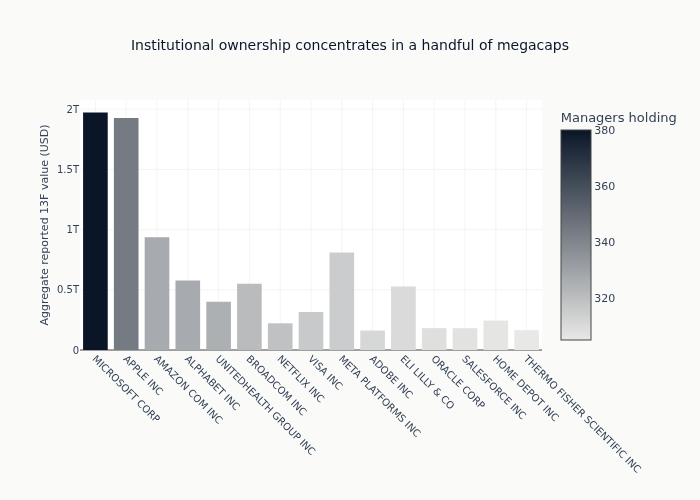

In [9]:
fig = px.bar(
    # Cast the manager count to a signed int so Plotly renders a continuous
    # color axis (a uint column is treated as categorical → off-palette hues).
    widely_held.head(15).with_columns(pl.col("num_managers").cast(pl.Int64)).to_pandas(),
    x="issuer",
    y="total_value",
    color="num_managers",
    title="Institutional ownership concentrates in a handful of megacaps",
    labels={
        "total_value": "Aggregate reported 13F value (USD)",
        "issuer": "Company",
        "num_managers": "Managers holding",
    },
    color_continuous_scale=[COLORS["silver_muted"], COLORS["blue"]],
)
# The rotated ticks are the company names, so the axis title is redundant;
# extra bottom/right margin keeps the longest label from clipping.
fig.update_layout(xaxis_tickangle=45, xaxis_title=None, margin=dict(b=150, r=120))
fig.show()

## 5. Build Ownership Edges for Knowledge Graphs

Two edge sets feed Chapter 23 graph models:

- **Manager → Stock (bipartite)**: weights are position value
- **Stock ↔ Stock (co-ownership)**: shared-manager intersection, useful
  for propagating signals across peers

In [10]:
manager_stock_edges = (
    top_holdings.select(["company_name", "issuer", "cusip", "value_thousands"])
    .group_by(["company_name", "issuer", "cusip"])
    .agg(pl.col("value_thousands").sum().alias("position_value"))
)
print(f"Manager-Stock edges: {len(manager_stock_edges):,}")
manager_stock_edges.head(10)

Manager-Stock edges: 639,124


company_name,issuer,cusip,position_value
str,str,str,i64
"""Arizona State Retirement Syste…","""ENACT HLDGS INC""","""29249E109""",329113
"""BLAIR WILLIAM & CO/IL""","""PORTILLOS INC""","""73642K106""",22398320
"""JANE STREET GROUP, LLC""","""HERON THERAPEUTICS INC""","""427746102""",660930
"""GATEWAY INVESTMENT ADVISERS LL…","""BIOGEN INC""","""09062X103""",8007918
"""BANK OF AMERICA CORP /DE/""","""KENON HLDGS LTD""","""Y46717107""",51261
"""BANK OF AMERICA CORP /DE/""","""SKILLSOFT CORP""","""83066P309""",6309
"""RHUMBLINE ADVISERS""","""ARKEMA SPONSORED ADR""","""041232109""",51922
"""WESTWOOD HOLDINGS GROUP INC""","""CITIGROUP INC""","""172967424""",224045
"""Williams Jones Wealth Manageme…","""GE VERNOVA INC COM""","""36828A101""",2986071


In [11]:
def build_co_ownership_edges(
    holdings_panel: pl.DataFrame,
    min_shared: int = 3,
    universe_cap: int = 500,
) -> pl.DataFrame:
    """Build stock-stock edges based on shared institutional owners.

    Caps the universe at `universe_cap` stocks (by number of unique
    managers) to avoid an O(n²) blow-up on the full cross-section.
    """
    stock_managers = (
        holdings_panel.group_by(["issuer", "cusip"])
        .agg(pl.col("company_name").alias("managers"))
        .with_columns(pl.col("managers").list.len().alias("n_managers"))
        .sort("n_managers", descending=True)
        .head(universe_cap)
    )

    stocks = stock_managers["issuer"].to_list()
    cusips = stock_managers["cusip"].to_list()
    manager_sets = [set(m) for m in stock_managers["managers"].to_list()]

    edges = []
    for i in range(len(stocks)):
        for j in range(i + 1, len(stocks)):
            shared = manager_sets[i] & manager_sets[j]
            if len(shared) >= min_shared:
                edges.append(
                    {
                        "stock_a": stocks[i],
                        "cusip_a": cusips[i],
                        "stock_b": stocks[j],
                        "cusip_b": cusips[j],
                        "shared_managers": len(shared),
                    }
                )
    return pl.DataFrame(
        edges,
        schema={
            "stock_a": pl.Utf8,
            "cusip_a": pl.Utf8,
            "stock_b": pl.Utf8,
            "cusip_b": pl.Utf8,
            "shared_managers": pl.Int64,
        },
    )


co_ownership = build_co_ownership_edges(
    top_holdings, min_shared=MIN_SHARED_MANAGERS, universe_cap=CO_OWNERSHIP_UNIVERSE
)
print(f"Co-ownership edges (≥{MIN_SHARED_MANAGERS} shared managers): {len(co_ownership):,}")
co_ownership.sort("shared_managers", descending=True).head(10)

Co-ownership edges (≥5 shared managers): 124,750


stock_a,cusip_a,stock_b,cusip_b,shared_managers
str,str,str,str,i64
"""MICROSOFT CORP""","""594918104""","""APPLE INC""","""037833100""",338
"""MICROSOFT CORP""","""594918104""","""UNITEDHEALTH GROUP INC""","""91324P102""",322
"""MICROSOFT CORP""","""594918104""","""ALPHABET INC""","""02079K305""",320
"""MICROSOFT CORP""","""594918104""","""AMAZON COM INC""","""023135106""",319
"""MICROSOFT CORP""","""594918104""","""NETFLIX INC""","""64110L106""",316
"""MICROSOFT CORP""","""594918104""","""VISA INC""","""92826C839""",313
"""MICROSOFT CORP""","""594918104""","""BROADCOM INC""","""11135F101""",312
"""MICROSOFT CORP""","""594918104""","""META PLATFORMS INC""","""30303M102""",308
"""MICROSOFT CORP""","""594918104""","""ELI LILLY & CO""","""532457108""",308


## 6. Bulk Data vs. Live Filing Monitoring

The bulk data set is assembled retroactively after each filing window
closes (a Q3 file covers Sep 1 – Nov 30 filings and is published in
early December). For trading applications where timeliness matters,
readers instead monitor individual filings as they land on EDGAR.

### 13F Filing Timeline

- **Quarter end**: Sep 30 (Q3 reports)
- **Filing deadline**: 45 days later → Nov 14
- **Individual filings**: Public immediately on EDGAR
- **Bulk window**: Sep 1 – Nov 30 (captures late/amended filings)
- **Bulk file published**: After the window closes (~early December)

### Why This Matters

If you are trading on "what are top managers accumulating?", the bulk
file is already stale by publication. Professional systems poll EDGAR
and parse filings within minutes — this is standard practice, not
front-running, since the information is public the instant it's
submitted.

### Two Ingestion Paths, One Canonical Schema

The `data/equities/positioning/13f_download.py` script supports both:

| Mode | Source | Scope | Use case |
| --- | --- | --- | --- |
| `--mode per-cik` (default) | SEC JSON submissions API + per-filing XML | Curated institution list × N recent quarters | Ch22/23 — named-manager history |
| `--mode bulk` | SEC quarterly zip | All ~7K filers × one quarter | This notebook — full cross-section |

Both modes write the same canonical schema, so downstream code does
not need to know which ingestion path produced the data.

## 7. Key Takeaways

1. **SEC bulk data is the canonical source for historical 13F analysis**:
   one ~80 MB quarterly file gives full-universe holdings from ~7K
   managers, no rate limits, no vendor fees.

2. **For live trading, monitor EDGAR directly**: bulk files are
   published after the filing window closes. The per-cik mode of the
   canonical downloader is the starting point for live ingestion.

3. **Institutional ownership is highly concentrated**: the top 500
   managers collectively report tens of trillions in 13F equity value.
   Remember this is reported 13F value, not AUM.

4. **Crowded trades are identifiable**: stocks held by hundreds of
   managers may face coordinated selling pressure during stress.

5. **Canonical schema keeps the pipeline simple**: the same downstream
   code consumes per-cik and bulk artifacts. New ingestion paths only
   need to land canonical columns in the right location.